# Machine Learning Optimization Strategies

## Final Project: Forecasting Apple Inc. Stock Trends with LSTM and Optimized Parameters

<br>

<hr>

## Project Overview
The project aims to predict Apple Inc.'s stock prices using a Long Short-Term
Memory (LSTM) model, a deep learning tool suited for time series data. I analyzed historical stock prices from 1980 to 2025 and optimized the model with Optuna to enhance accuracy.      
This report explains the data preparation, model development, testing, and results analysis. The findings show that the LSTM effectively captures recent and long-term stock patterns, producing reliable predictions. This work demonstrates the value of deep learning in financial forecasting.


## Apple Stock Data (2025)

1. Context / Introduction     
Apple Inc. (AAPL) is one of the most influential technology companies in the world, with its stock being closely monitored by investors, analysts, and financial institutions. This dataset provides historical stock price data for Apple, allowing for various analyses, including stock market prediction, trend analysis, and financial modeling.


2. Content     
The dataset contains historical daily stock price data for Apple Inc., capturing price movements from 1980 to 2025. This data is valuable for:
 - Predicting stock price trends using machine learning models
 - Analyzing price fluctuations over time
 - Identifying historical patterns and correlations
 - Backtesting trading strategies

6. Variables and Shape
 - Date (Unnamed: 0): The date of the stock price record
 - Adj Close: Adjusted closing price after stock splits and dividends
 - Close: Closing price at the end of the trading day
 - High: Highest price of the day
 - Low: Lowest price of the day
 - Open: Opening price of the day
 - Volume: The number of shares traded on that day
 - Dataset shape: 11,107 rows x 7 columns

This dataset is a great resource for stock market prediction and financial analysis, helping researchers and traders develop better forecasting models.

<br>

<hr>

## Model Choice Justification

LSTM is an excellent choice for Stock Market Prediction due to its ability to model sequential dependencies and capture long-term patterns in financial data. Here’s why LSTM is particularly well-suited for this problem:

1. **Handling Temporal Dependencies**     
Stock prices exhibit sequential dependencies, meaning that past prices influence future movements. LSTMs are designed to remember long-term patterns, making them highly effective for analyzing financial time series data.

2. **Avoiding the Vanishing Gradient Problem**     
Traditional RNNs struggle with long sequences due to vanishing gradients. LSTMs mitigate this issue with gated mechanisms (forget, input, and output gates), allowing them to retain relevant historical information over extended periods.

3. **Capturing Non-Linear Relationships**     
Stock market data is highly non-linear due to external factors like economic indicators, news sentiment, and investor behavior. LSTMs, with their deep learning architecture, can learn complex, non-linear patterns better than traditional statistical methods like ARIMA.

4. **Ability to Handle Noisy Data**     
Financial time series data is often noisy and volatile. LSTMs can smooth out fluctuations and extract meaningful trends, leading to more reliable predictions.

5. **Proven Success in Time Series Forecasting**
LSTMs have demonstrated state-of-the-art performance in time series forecasting, making them widely used in financial applications such as stock price prediction, volatility modeling, and algorithmic trading.

### Mandatory installs

In [1]:
# !pip install optuna
# !pip install scikit-optimize

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
import tensorflow as tf
from keras import Model
from keras.layers import Input, Dense, Dropout, LSTM, LayerNormalization, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import optuna
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")
sns.set_style('whitegrid')

### GPU Availability
Checks if a GPU is available for TensorFlow. If a GPU is detected, it enables memory growth to prevent TensorFlow from allocating all GPU memory at once. Otherwise, it prints a message indicating that the code is running on the CPU.

In [3]:
# Check if GPU is available
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print(f"GPU available: {physical_devices[0]}")
else:
    print("Running on CPU")

GPU available: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


 ## Load Data
 loads Apple's stock data from a CSV file and processes it into a clean DataFrame. It renames the first column to "Date," checks for missing values, converts it to a datetime format, removes invalid dates, and sets it as the index. Then, it stores the company name and displays the last few rows of the DataFrame.

In [4]:
stock_raw = pd.read_csv("/content/apple_stock.csv")
stock_df = (stock_raw
            .rename(columns={'Unnamed: 0': 'Date'}) # Rename columns for clarity
            .pipe(lambda x: print(f"Rows with NaN in 'Date': {x['Date'].isna().sum()}") or x)  # Check how many rows got NaT in 'time' after conversion
            .assign(Date=pd.to_datetime(stock_raw['Unnamed: 0'])) # Assign the converted 'Date'
            .dropna(subset=['Date'])   # Drop rows with invalid time
            .set_index('Date')  # Set time as index
            )
comp_name = "Apple Inc."
stock_df.tail()

Rows with NaN in 'Date': 0


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2024-12-27,255.589996,255.589996,258.700012,253.059998,257.829987,42355300
2024-12-30,252.199997,252.199997,253.500000,250.750000,252.229996,35557500
2024-12-31,250.419998,250.419998,253.279999,249.429993,252.440002,39480700
2025-01-02,243.850006,243.850006,249.100006,241.820007,248.929993,55558000
2025-01-03,243.860001,243.860001,244.179993,241.889999,243.369995,15135053


Let's dive deeper into interpreting the dataset:
- **Adj Close (Adjusted Close):** The adjusted closing price, which accounts for dividends, stock splits, and other corporate adjustments.
- **Close:** The stock's closing price at the end of the period.
- **High:** The highest price reached by the stock during the period.
- **Low:** The lowest price reached by the stock during the period.
- **Open:** The stock's opening price at the beginning of the period.
- **Volume:** The total number of shares traded during the period.

In [5]:
print(f"Company Name: {comp_name}")
print(f"Dataframe shape: {stock_df.shape}")
stock_df.describe()

Company Name: Apple Inc.
Dataframe shape: (11107, 6)


,Adj Close,Close,High,Low,Open,Volume
count,11107.000000,11107.000000,11107.000000,11107.000000,11107.000000,1.110700e+04
mean,23.522229,24.357607,24.598169,24.092608,24.339076,3.154341e+08
std,49.767881,50.217498,50.691902,49.682631,50.166818,3.348735e+08
min,0.037815,0.049107,0.049665,0.049107,0.049665,0.000000e+00
25%,0.243402,0.300290,0.306362,0.292411,0.300090,1.111164e+08
50%,0.446682,0.542411,0.553393,0.534598,0.542679,2.036944e+08
75%,18.260086,21.397143,21.569285,21.115715,21.367679,3.960418e+08
max,259.019989,259.019989,260.100006,257.630005,258.190002,7.421641e+09


Now that we understand what each column represents, I'm filtering records from January 2010 to 2023 to focus on 13 years of stock data.

In [6]:
# Filter data
stock_df_filtered = stock_df['2010-01-01':'2023-12-31']

In this next step, I'll create line plots to compare different visualizations. Each subplot will show the trend of a specific numerical column over time. Then, I'll adjust the layout and display the plots for Adj Close price, Close price, High price, Low price, Open price, and Volume over time.

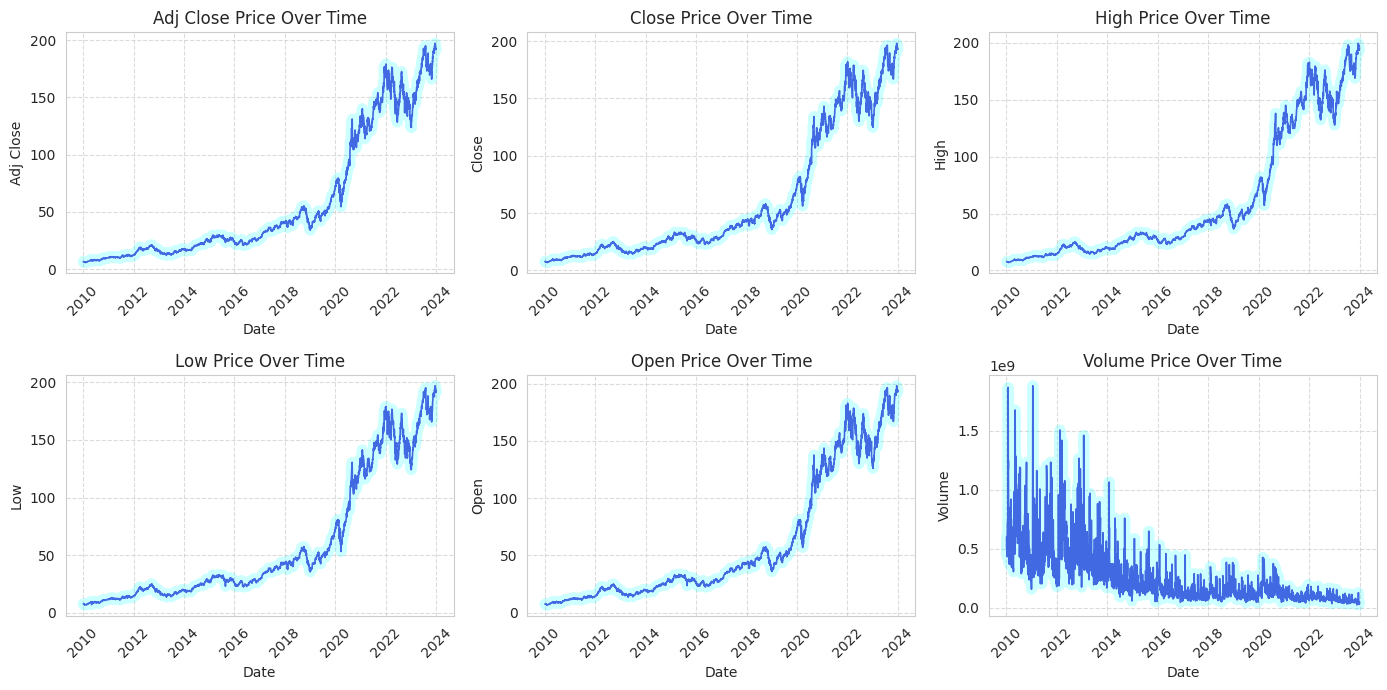

In [7]:
# Style
sns.set_style('whitegrid')
num_cols = stock_df.select_dtypes(include={'int64', 'float64'}).columns

# Create the visualization
f, ax = plt.subplots(2, 3, figsize=(14, 7))
ax = ax.flatten()

for index, cols in enumerate(num_cols):
    sns.lineplot(data=stock_df_filtered, x=stock_df_filtered.index, y=cols, ax=ax[index], color="cyan", alpha=0.2, linewidth=8)
    sns.lineplot(data=stock_df_filtered, x=stock_df_filtered.index, y=cols, ax=ax[index], color="royalblue", linewidth=1.2)
    ax[index].set_title(f'{cols} Price Over Time')
    ax[index].grid(True, linestyle="--", alpha=0.7)
    ax[index].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [8]:
stock_df_filtered.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-01-04,6.447411,7.643214,7.660714,7.585000,7.622500,493729600
2010-01-05,6.458559,7.656429,7.699643,7.616071,7.664286,601904800
2010-01-06,6.355827,7.534643,7.686786,7.526786,7.656429,552160000
2010-01-07,6.344076,7.520714,7.571429,7.466071,7.562500,477131200
2010-01-08,6.386255,7.570714,7.571429,7.466429,7.510714,447610800


After filtering records from 2010 to 2024, I now create a line plot showing the 'Trading' volume of Apple Inc. The results is a line plot with the y-axis displaying the volume (Sales volume) and the x-axis showing the date (years).
Building on this, In the next two cells I create a line plot showing the 'Annual Trading' and 'Annual Closing Prices' volume of Apple Inc.      

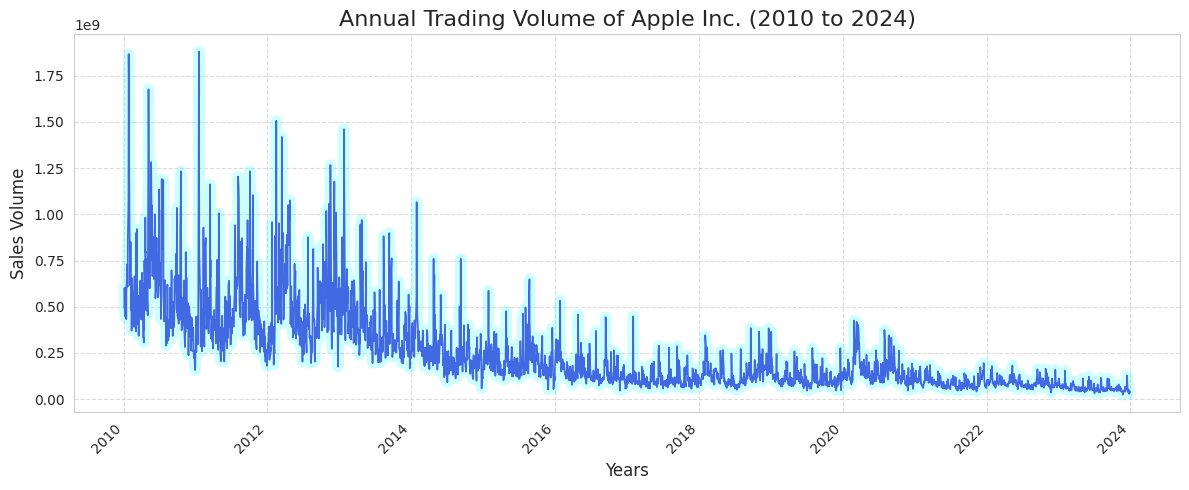

In [9]:
# Style
sns.set_style('whitegrid')

# Create the visualization
plt.figure(figsize=(12, 5))
sns.lineplot(data=stock_df_filtered, x=stock_df_filtered.index, y="Volume", color="cyan", alpha=0.2, linewidth=8)
sns.lineplot(data=stock_df_filtered, x=stock_df_filtered.index, y="Volume", color="royalblue", linewidth=1.2)
plt.title(f"Annual Trading Volume of {comp_name} (2010 to 2024)", fontsize=16, ha='center')
plt.xlabel("Years", fontsize=12)
plt.ylabel('Sales Volume', fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Annual Closing Prices

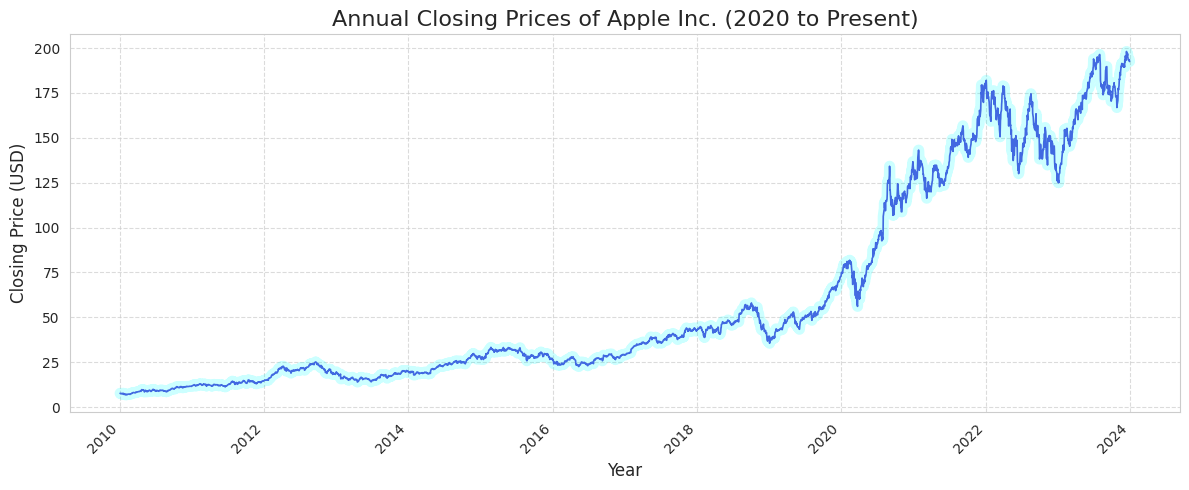

In [10]:
# Style
sns.set_style('whitegrid')

# Create the visualization
plt.figure(figsize=(12, 5))

sns.lineplot(data=stock_df_filtered, x=stock_df_filtered.index, y="Close", color="cyan", alpha=0.2, linewidth=8)
sns.lineplot(data=stock_df_filtered, x=stock_df_filtered.index, y="Close", color="royalblue", linewidth=1.2)
plt.title(f'Annual Closing Prices of {comp_name} (2020 to Present)', fontsize=16, ha='center')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Closing Price (USD)', fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In the next visualization lets plot a line showing the 'Close Price with Moving Averages' of Apple Inc. from 2010 to 2024, comparing `10-day`, `60-day`, and `180-day` periods.

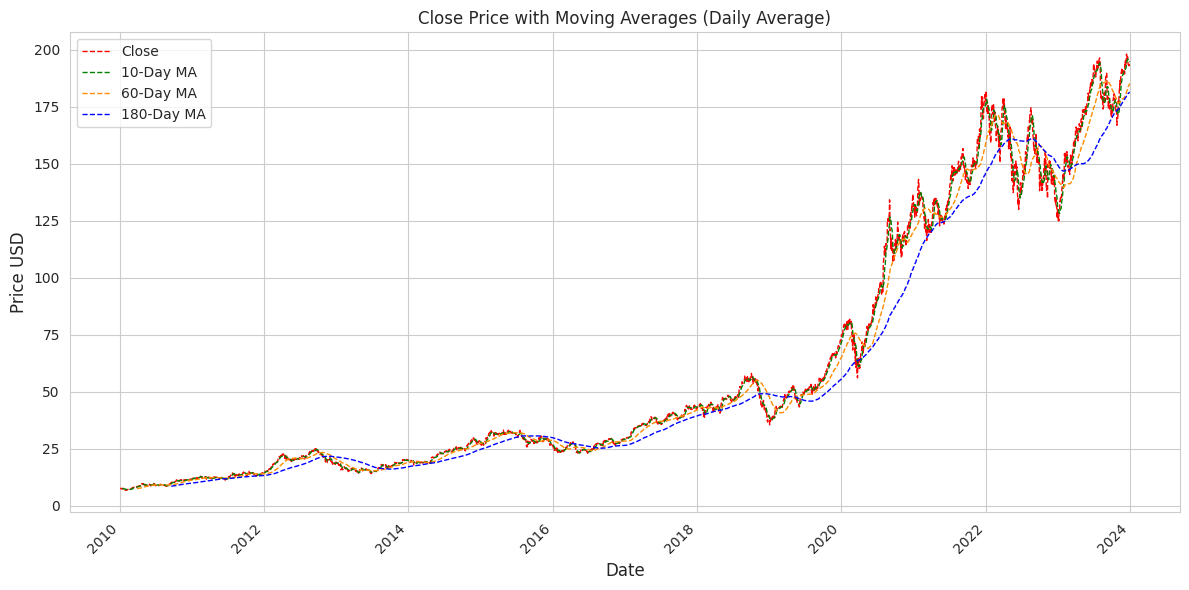

In [11]:
# Style
sns.set_style('whitegrid')

#Calculate the mean for 10, 60 and 180 days
stock_df_filtered['MA10'] = stock_df_filtered['Close'].rolling(window=10).mean()
stock_df_filtered['MA60'] = stock_df_filtered['Close'].rolling(window=60).mean()
stock_df_filtered['MA180'] = stock_df_filtered['Close'].rolling(window=180).mean()

plt.figure(figsize=(12, 6))
plt.plot(stock_df_filtered.index, stock_df_filtered['Close'], label='Close', color='red', linestyle='--', linewidth=1)
plt.plot(stock_df_filtered.index, stock_df_filtered['MA10'], label='10-Day MA', color='green', linestyle='--', linewidth=1)
plt.plot(stock_df_filtered.index, stock_df_filtered['MA60'], label='60-Day MA', color='darkorange', linestyle='--', linewidth=1)
plt.plot(stock_df_filtered.index, stock_df_filtered['MA180'], label='180-Day MA', color='blue', linestyle='--', linewidth=1)

plt.title('Close Price with Moving Averages (Daily Average)')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price USD', fontsize=12)
plt.legend()

plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

Now, let's prepare the data for splitting into train, test, and validation sets. First, I'll create a copy of the original DataFrame.

In [12]:
df = stock_df.copy()
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1980-12-12,0.098834,0.128348,0.128906,0.128348,0.128348,469033600
1980-12-15,0.093678,0.121652,0.122210,0.121652,0.122210,175884800
1980-12-16,0.086802,0.112723,0.113281,0.112723,0.113281,105728000
1980-12-17,0.088951,0.115513,0.116071,0.115513,0.115513,86441600
1980-12-18,0.091530,0.118862,0.119420,0.118862,0.118862,73449600


Check for missing data

In [13]:
df.isnull().sum()

,0
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0


## Preprocessing
Next, I'll perform several preprocessing steps on the DataFrame:

1. **Feature Selection:** Selecting relevant data (e.g., 'Close' price).

2. **Scaling/Normalization:** Adjusting the data range to improve model processing and learning.

3. **Sequence Creation:** Splitting data into sequences for predicting future values, a crucial step in time-series prediction, as taught by Prof. Mohammad.

4. **Training and Testing split:** The data is divided into training and test, validation sets.

In [14]:
# Filter historical data from 2000 to 2024
df_filtered = df['2010-01-01':'2024-01-01']

# Feature Selection
df_close = df_filtered['Close'].values.reshape(-1, 1)
df_close.shape

(3522, 1)

Let's check the DataFrame and its shape:

In [15]:
display(df_filtered)

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-01-04,6.447411,7.643214,7.660714,7.585000,7.622500,493729600
2010-01-05,6.458559,7.656429,7.699643,7.616071,7.664286,601904800
2010-01-06,6.355827,7.534643,7.686786,7.526786,7.656429,552160000
2010-01-07,6.344076,7.520714,7.571429,7.466071,7.562500,477131200
2010-01-08,6.386255,7.570714,7.571429,7.466429,7.510714,447610800
...,...,...,...,...,...,...
2023-12-22,192.656174,193.600006,195.410004,192.970001,195.179993,37122800
2023-12-26,192.108856,193.050003,193.889999,192.830002,193.610001,28919300
2023-12-27,192.208374,193.149994,193.500000,191.089996,192.490005,48087700


## Scaling/Normalization

Next step, scale the 'Close' column data using `MinMaxScaler`, normalizing the values to a range between `0` and `1`. Then, print the shape and the scaled data.

In [16]:
# Normalization using MinMax Scale
scaler = MinMaxScaler(feature_range=(0, 1))
df_close_scale = scaler.fit_transform(df_close)
print(df_close_scale.shape)
df_close_scale

(3522, 1)


array([[0.00410081],
       [0.00416991],
       [0.00353313],
       ...,
       [0.97406547],
       [0.97631386],
       [0.97082368]])

## Create sequences for LSTM
Next, I define a function to create data sequences for LSTM training. Each sequence consists of seq_length `(60)` days of historical data to predict the next day's value. Then, I apply this function to the scaled 'Close' data and print the shapes of the resulting input `(X)` and output `(y)` arrays.

In [17]:
# Create sequences for LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 60  # Use 60 days to predict the next day
X, y = create_sequences(df_close_scale, seq_length)
print(X.shape, y.shape)

(3462, 60, 1) (3462, 1)


## Split into train, validation, and test sets
Now, let's split the data into training `(80%)`, validation `(10%)`, and test `(10%)` sets. Then, reshape the input data for LSTM models, ensuring the format is `[samples, timesteps, features]`.

In [18]:
# Split into train, validation, and test sets
train_size = int(len(X) * 0.8)
val_size = int(len(X) * 0.1)
X_train, X_temp, y_train, y_temp = X[:train_size], X[train_size:], y[:train_size], y[train_size:]
X_val, X_test, y_val, y_test = X_temp[:val_size], X_temp[val_size:], y_temp[:val_size], y_temp[val_size:]

# Reshape for LSTM [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"X_train Shape:{X_train.shape}")
print(f"X_test Shape:{X_test.shape}")
print(f"y_train Shape:{y_train.shape}")
print(f"y_test Shape:{y_test.shape}")

X_train Shape:(2769, 60, 1)
X_test Shape:(347, 60, 1)
y_train Shape:(2769, 1)
y_test Shape:(347, 1)


## Visualizing training and testing periods
In this step, I extract the dates correpsonding to the training and testing periods from the dataset and prints the start and end dates for both. I also generate a plot visaulizing the 'Close' price over time, highlighting the training period in blue and the testing period in orange to better illustrates the data split.

Training data period: 2010-03-31 to 2021-03-30
Testing data period: 2021-03-31 to 2023-12-29


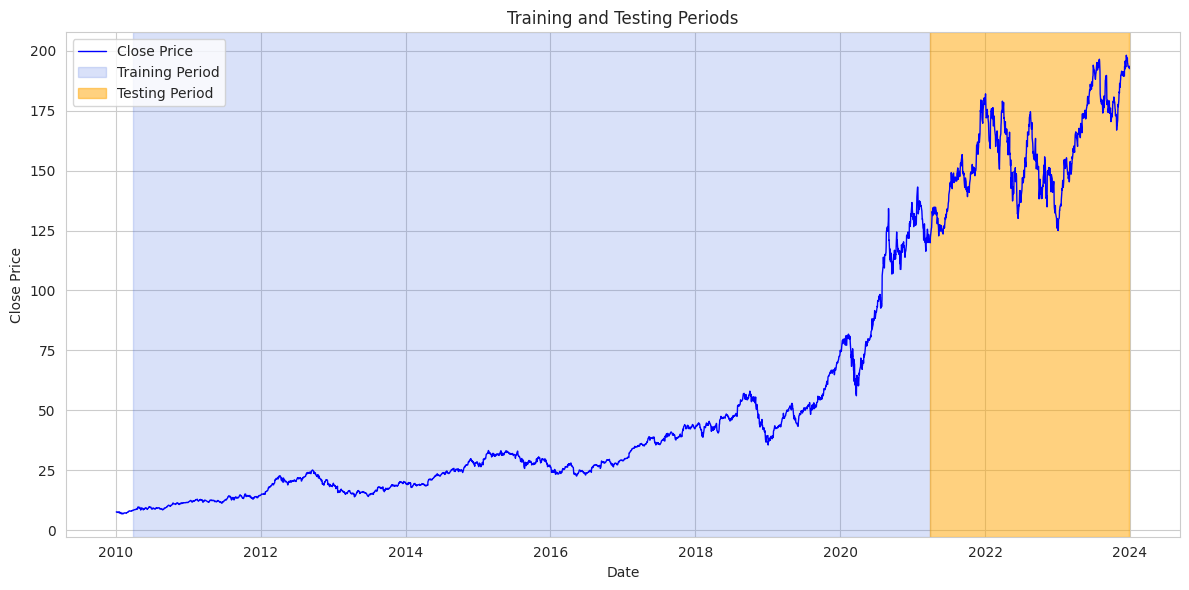

In [19]:
# Extratc Index
dates = df_filtered.index[seq_length:]

train_dates = dates[:train_size]
test_dates = dates[train_size:]

# Check Period
print("Training data period: {} to {}".format(train_dates[0].strftime('%Y-%m-%d'), train_dates[-1].strftime('%Y-%m-%d')))
print("Testing data period: {} to {}".format(test_dates[0].strftime('%Y-%m-%d'), test_dates[-1].strftime('%Y-%m-%d')))

# Check Plot
plt.figure(figsize=(12, 6))
plt.plot(df_filtered.index, df_filtered['Close'], label='Close Price', color='blue', linewidth=1)
plt.axvspan(train_dates[0], train_dates[-1], color='royalblue', alpha=0.2, label='Training Period')
plt.axvspan(test_dates[0], test_dates[-1], color='orange', alpha=0.5, label='Testing Period')
plt.title('Training and Testing Periods')
plt.xlabel('Date')
plt.ylabel('Close Price')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Model Implementation
Now, let's focus on the model implementation.     
In this step, I create an LSTM model function with hyperparameters tuned using Optuna. This includes parameters such as the `number of LSTM units`, `dropout rate`, and `learning rate`. The model is designed to `run on a GPU` and incorporates `early stopping` to prevent overfitting. I also define an `objective function` for Optuna, which optimizes the batch size and evaluates the model on the validation set.

In [20]:
def create_lstm_model(trial, input_shape):
    model = Sequential()

    # Hyperparameters to tune
    lstm_units = trial.suggest_int('lstm_units', 32, 256, step=32)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.2)
    learning_rate = trial.suggest_float('learning_rate', 0.001, 0.005, log=True)
    num_lstm_layers = trial.suggest_int('num_lstm_layers', 1, 2)

    # Force model creation on GPU
    with tf.device('/GPU:0'):
        for i in range(num_lstm_layers):
            return_sequences = (i < num_lstm_layers - 1)
            model.add(LSTM(units=lstm_units, return_sequences=return_sequences, input_shape=input_shape))
            model.add(BatchNormalization())
            model.add(Dropout(dropout_rate))
        model.add(Dense(units=25, activation='relu'))
        model.add(Dense(units=1))  # Output layer

        # Compile with custom optimizer
        optimizer = Adam(learning_rate=learning_rate)
        model.compile(optimizer=optimizer, loss='mean_squared_error')

    return model

# Objective function for Optuna
def objective(trial, X_train, y_train, X_val, y_val, input_shape):
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    model = create_lstm_model(trial, input_shape)

    # Early stopping to avoid overfitting
    early_stopping = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

    # Train model on GPU
    with tf.device('/GPU:0'):
        history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                            epochs=20, batch_size=batch_size, callbacks=[early_stopping], verbose=1)

        # Evaluate on validation set
        val_loss = model.evaluate(X_val, y_val, verbose=1)

    return val_loss

## Training and Evaluation
Next, I define three functions for evaluating and visualizing the model's performance:

1. **Compute_metrics:** This function calculates evaluation metrics like `MSE`, `MAE`, `MAPE`, `SMAPE`, and `R²`, converting the predicted and true values back to their original scale using the inverse of the scaler.
  - **Mean Square Error (MSE)**: Measures the average squared difference between predicted `(ŷi)` and actual `(yi)` values, calculated as `MSE = (1/n) * Σ(ŷi - yi)`. It emphasizes larger errors due to squaring, making it sensitive to outliers.

  - **Mean Absolute Error (MAE)**: Computes the average absolute difference, `MAE = (1/n) * Σ|ŷi - yi|`, providing a straightforward measure of error magnitude without exaggerating outliers.

  - **Mean Absolute Percentage Error (MAPE)**: Expresses the average absolute error as a percentage of actual values, `MAPE = (1/n) * Σ(|ŷi - yi| / yi) * 100`. It's intuitive for comparing relative accuracy but can be unstable if actual values approach zero.

  - **Symmetric Mean Absolute Percentage Error (SMAPE)**: Adjusts MAPE for symmetry, calculated as `SMAPE = (100/n) * Σ(|ŷi - yi| / (|yi| + |ŷi|))`, reducing bias when predictions and actual values differ in scale.

  - **Coefficient of Determination (R²)**: Measures how well predictions explain variance in actual data, defined as `R² = 1 - (Σ(yi - ŷi)² / Σ(yi - ȳ)²)`, where `ȳ` is the mean of the actual value. Values closer to 1 indicates a better fit.



2. **Print_metrics**: This function prints the calculated metrics in a clean and readable format, along with the training time.

3. **Plot_loss**: This function plots the training and validation loss over epochs to visualize the model's learning progress.

In [21]:
# Compute evaluation metrics
def compute_metrics(y_true, y_pred, training_time):
    y_true_inv = scaler.inverse_transform(y_true.reshape(-1, 1))
    y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1))
    mse = mean_squared_error(y_true_inv, y_pred_inv)
    mae = mean_absolute_error(y_true_inv, y_pred_inv)
    mape = np.mean(np.abs((y_true_inv - y_pred_inv) / (y_true_inv + 1e-10))) * 100
    smape = 200 * np.mean(np.abs(y_pred_inv - y_true_inv) / (np.abs(y_pred_inv) + np.abs(y_true_inv) + 1e-10))
    r2 = r2_score(y_true_inv, y_pred_inv)

    return {'mse': mse, 'mae': mae, 'mape': mape, 'smape': smape, 'r2': r2, 'training_time': training_time}

# Print metrics
def print_metrics(metrics, method):
    print(f"\n{method} Results:")
    print(f"MSE: {metrics['mse']:.4f} | MAE: {metrics['mae']:.4f} | MAPE: {metrics['mape']:.2f}% | "
          f"SMAPE: {metrics['smape']:.2f}% | R²: {metrics['r2']:.4f}")
    print(f"Tuning Time: {metrics['training_time']:.2f}s")

# Plot loss history
def plot_loss(history, method):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{method} - Loss vs Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

Now, I define a `plot_predicted_vs_actual` function to visualize the relationship between the predicted and actual values. It first converts both the true and predicted values back to their original scale, then creates a scatter plot showing the `predicted` versus `actual` values.

In [22]:
# Plot Predicted vs Actual Values
def plot_predicted_vs_actual(y_true, y_pred, method):
    y_true_inv = scaler.inverse_transform(y_true.reshape(-1, 1)).flatten()
    y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

    plt.figure(figsize=(10, 6))
    plt.scatter(y_true_inv, y_pred_inv, alpha=0.5, label='Predicted vs Actual')
    plt.plot([min(y_true_inv), max(y_true_inv)], [min(y_true_inv), max(y_true_inv)],
             color='red', linestyle='--', label='Perfect Prediction')
    plt.title(f'{method} - Predicted vs Actual Values')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.legend()
    plt.grid(True)
    plt.show()

Now, it's time to build the function to run the optimization with Optuna for hyperparameter tuning of the LSTM model. It trains the model using the best hyperparameters found during the optimization process, evaluates the model on the test set, and calculates various metrics like `MSE`, `MAE`, `MAPE`, `SMAPE` and `R²`. The function also prints the optimization results, including the `best hyperparameters` and `metrics`, and plots the training and validation loss over epochs. Additionally, it returns the `best hyperparameters`, `metrics`, `training history`, `final model`, and `predicted values`.

In [23]:
# Optimization function
def run_optimization(sampler, X_train, y_train, X_val, y_val, X_test, y_test, input_shape, method, n_trials=15):
    study = optuna.create_study(direction='minimize', sampler=sampler)
    start_time = time.time()
    study.optimize(lambda trial: objective(trial, X_train, y_train, X_val, y_val, input_shape), n_trials=n_trials)
    tuning_time = time.time() - start_time

    # Train final model with best params on GPU
    best_model = create_lstm_model(study.best_trial, input_shape)
    early_stopping = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    with tf.device('/GPU:0'):
        history = best_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                                epochs=20, batch_size=study.best_params['batch_size'],
                                callbacks=[early_stopping], verbose=1)

        # Predict and evaluate
        y_pred = best_model.predict(X_test, verbose=0)

    metrics = compute_metrics(y_test, y_pred, tuning_time)
    print_metrics(metrics, method)
    print(f"Best Hyperparameters: {study.best_params}")

    # Plot loss
    plot_loss(history, method)

    return study.best_params, metrics, history, best_model, y_pred

Next, let's run the hyperparameter optimization.
Here I'm using three different Optuna samplers:
- RandomSampler
- TPESampler
- GPSampler

For each sampler, the `run_optimization` function is called to find the best hyperparameters, train the model, and evaluate it. The results are stored in variables corresponding to each method (e.g., `random search`, `Tree-Structure Parzen Estimator`, and `Gaussian Process`), and include the best hyperparameters, metrics, training history, the final trained model, and predictions.

[I 2025-04-02 00:30:58,008] A new study created in memory with name: no-name-17b50777-2a10-4dfb-8d4a-485bfb445922


Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.8307 - val_loss: 0.0071
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0620 - val_loss: 0.0438
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0074 - val_loss: 0.0093
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0029 - val_loss: 0.0092
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0017 - val_loss: 0.0401
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0065 


[I 2025-04-02 00:31:10,579] Trial 0 finished with value: 0.0071004037745296955 and parameters: {'batch_size': 64, 'lstm_units': 256, 'dropout_rate': 0.15514187260275156, 'learning_rate': 0.0028502474519257978, 'num_lstm_layers': 2}. Best is trial 0 with value: 0.0071004037745296955.


Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.9031 - val_loss: 0.1495
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1946 - val_loss: 0.4163
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0630 - val_loss: 0.3141
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0115 - val_loss: 0.2366
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0053 - val_loss: 0.2865
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1132 


[I 2025-04-02 00:31:18,320] Trial 1 finished with value: 0.14954006671905518 and parameters: {'batch_size': 64, 'lstm_units': 192, 'dropout_rate': 0.14672343133288518, 'learning_rate': 0.0023297423948430967, 'num_lstm_layers': 2}. Best is trial 0 with value: 0.0071004037745296955.


...

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0711 - val_loss: 0.3596
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0021 - val_loss: 0.3352
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0012 - val_loss: 0.3197
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0017 - val_loss: 0.3108
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0013 - val_loss: 0.2841
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.9313e-04 - val_loss: 0.2811
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.9119e-04 - val_loss: 0.2604
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.1553e-04 - val_loss: 0.2448
Epoch 9/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.3136e-04 - val_loss: 0.1958
Epoch 10/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.4066e-04 - val_loss: 0.1669
Epoch 11/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.0168e-04 - val_loss: 0.1585
Epoch 12/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/st

[I 2025-04-02 00:36:17,265] Trial 13 finished with value: 0.0025702405255287886 and parameters: {'batch_size': 64, 'lstm_units': 128, 'dropout_rate': 0.18013211300633034, 'learning_rate': 0.0038222144393388934, 'num_lstm_layers': 1}. Best is trial 11 with value: 0.00030788895674049854.


Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0554 - val_loss: 0.3600
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0023 - val_loss: 0.3016
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0017 - val_loss: 0.2834
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0016 - val_loss: 0.2572
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 0.1939
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0016 - val_loss: 0.0996
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0011 - val_loss: 0.0644
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0010 - val_loss: 0.0148
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 0.0053
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.9993e-04 - val_loss: 4.4216e-04
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.9363e-04 - val_loss: 0.0023
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 

[I 2025-04-02 00:36:35,577] Trial 14 finished with value: 0.0002788989513646811 and parameters: {'batch_size': 32, 'lstm_units': 160, 'dropout_rate': 0.11353881477864586, 'learning_rate': 0.0026578229953175326, 'num_lstm_layers': 1}. Best is trial 14 with value: 0.0002788989513646811.


Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0386 - val_loss: 0.3249
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0019 - val_loss: 0.3125
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0014 - val_loss: 0.2736
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.8182e-04 - val_loss: 0.2670
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0010 - val_loss: 0.1916
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 0.1214
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.9965e-04 - val_loss: 0.0418
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - val_loss: 0.0262
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.1860e-04 - val_loss: 0.0022
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.0567e-04 - val_loss: 9.0017e-04
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.7119e-04 - val_loss: 0.0095
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/st

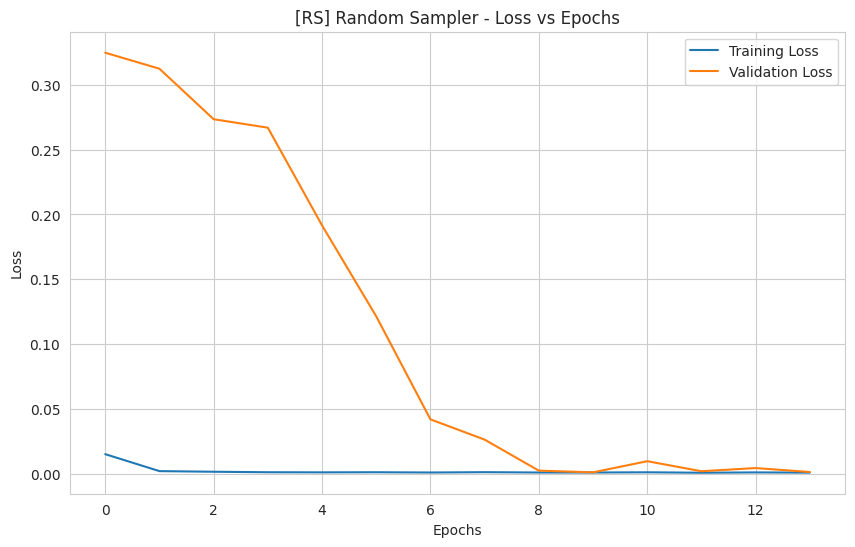

[I 2025-04-02 00:36:52,002] A new study created in memory with name: no-name-0b094474-e95c-44a2-8722-9895260010ae


Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0501 - val_loss: 0.3394
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0028 - val_loss: 0.3156
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0021 - val_loss: 0.2961
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0017 - val_loss: 0.2709
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0014 - val_loss: 0.1940
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - val_loss: 0.1047
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 0.0643
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 0.0110
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.8746e-04 - val_loss: 0.0034
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.3909e-04 - val_loss: 0.0038
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.6060e-04 - val_loss: 0.0054
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9

[I 2025-04-02 00:37:15,012] Trial 0 finished with value: 0.0008635199046693742 and parameters: {'batch_size': 32, 'lstm_units': 256, 'dropout_rate': 0.1706605185923403, 'learning_rate': 0.001573415564295962, 'num_lstm_layers': 1}. Best is trial 0 with value: 0.0008635199046693742.


Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.8598 - val_loss: 0.6342
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0869 - val_loss: 0.4674
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0458 - val_loss: 0.1817
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0246 - val_loss: 0.2844
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0165 - val_loss: 0.1180
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0122 - val_loss: 0.0671
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0085 - val_loss: 0.0491
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0067 - val_loss: 0.0278
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0047 - val_loss: 0.0076
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0034 - val_loss: 0.0032
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0033 - val_loss: 0.0154
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0

[I 2025-04-02 00:37:36,109] Trial 1 finished with value: 0.0031512377317994833 and parameters: {'batch_size': 32, 'lstm_units': 160, 'dropout_rate': 0.1575415121056261, 'learning_rate': 0.004308590328092928, 'num_lstm_layers': 2}. Best is trial 0 with value: 0.0008635199046693742.


...

Epoch 1/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0240 - val_loss: 0.3042
Epoch 2/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0037 - val_loss: 0.2672
Epoch 3/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0021 - val_loss: 0.1055
Epoch 4/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0016 - val_loss: 0.0355
Epoch 5/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0018 - val_loss: 0.0033
Epoch 6/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0015 - val_loss: 3.8073e-04
Epoch 7/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0012 - val_loss: 0.0017
Epoch 8/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 8.6120e-04 - val_loss: 0.0129
Epoch 9/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0011 - val_loss: 0.0042
Epoch 10/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 9.6422e-04 - val_loss: 0.0034
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5422e-04 


[I 2025-04-02 00:41:47,823] Trial 13 finished with value: 0.00038073319592513144 and parameters: {'batch_size': 16, 'lstm_units': 96, 'dropout_rate': 0.13802670837680417, 'learning_rate': 0.002243380098302994, 'num_lstm_layers': 1}. Best is trial 12 with value: 0.00028598346398212016.


Epoch 1/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0124 - val_loss: 0.2938
Epoch 2/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0026 - val_loss: 0.2672
Epoch 3/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0017 - val_loss: 0.1302
Epoch 4/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0014 - val_loss: 0.0223
Epoch 5/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - val_loss: 3.4514e-04
Epoch 6/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0017 - val_loss: 0.0170
Epoch 7/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0014 - val_loss: 3.5548e-04
Epoch 8/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 2.8335e-04
Epoch 9/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 0.0168
Epoch 10/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0012 - val_loss: 0.0027
Epoch 11/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.8078e-04 - val_loss: 0.0036
Epoch 12/20
174/174 ━━━━━━━━━━━━━

[I 2025-04-02 00:42:16,011] Trial 14 finished with value: 0.0002833537582773715 and parameters: {'batch_size': 16, 'lstm_units': 64, 'dropout_rate': 0.13518552967032493, 'learning_rate': 0.002133363523420263, 'num_lstm_layers': 1}. Best is trial 14 with value: 0.0002833537582773715.


Epoch 1/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0224 - val_loss: 0.3194
Epoch 2/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0021 - val_loss: 0.2461
Epoch 3/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0016 - val_loss: 0.0830
Epoch 4/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0016 - val_loss: 0.0114
Epoch 5/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0014 - val_loss: 2.8937e-04
Epoch 6/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0017 - val_loss: 0.0060
Epoch 7/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0010 - val_loss: 0.0014
Epoch 8/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.9354e-04 - val_loss: 6.4689e-04
Epoch 9/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.9628e-04 - val_loss: 0.0162

[TPE] TPE Sampler Results:
MSE: 10.1840 | MAE: 2.4606 | MAPE: 1.54% | SMAPE: 1.53% | R²: 0.9720
Tuning Time: 324.01s
Best Hyperparameters: {'batch_size': 16, 'lstm_units': 64, 'dropout_rate': 0.13518552967032

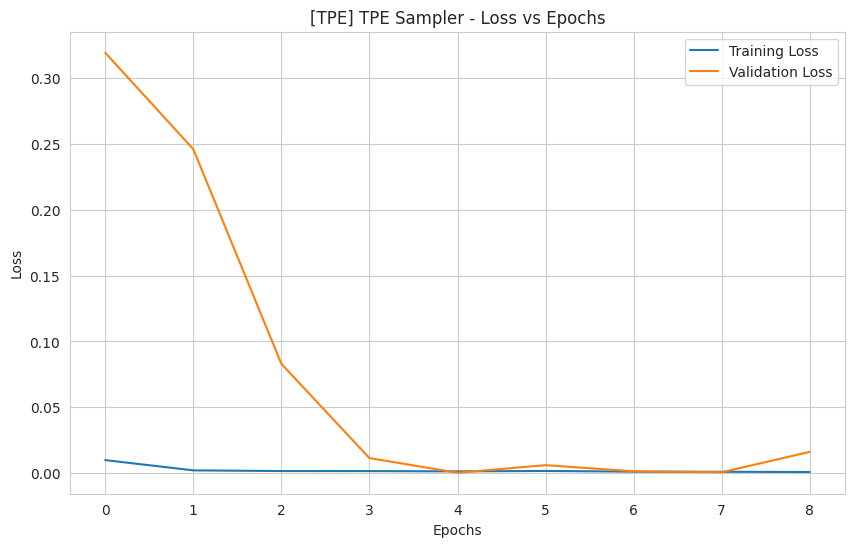

[I 2025-04-02 00:42:36,411] A new study created in memory with name: no-name-30918fa4-933b-4fef-bc46-1e8133bd69b4


Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.4321 - val_loss: 0.2116
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0407 - val_loss: 0.0064
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0035 - val_loss: 0.0876
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0022 - val_loss: 0.1986
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0021 - val_loss: 0.2878
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0012 - val_loss: 0.2743
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0073 


[I 2025-04-02 00:42:48,550] Trial 0 finished with value: 0.006376354489475489 and parameters: {'batch_size': 32, 'lstm_units': 128, 'dropout_rate': 0.12292749117903862, 'learning_rate': 0.003110878186660158, 'num_lstm_layers': 2}. Best is trial 0 with value: 0.006376354489475489.


Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0430 - val_loss: 0.3409
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0037 - val_loss: 0.3020
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0028 - val_loss: 0.3389
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0035 - val_loss: 0.2354
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0018 - val_loss: 0.2044
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - val_loss: 0.1446
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0016 - val_loss: 0.1026
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0016 - val_loss: 0.0308
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 0.0047
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0013 - val_loss: 2.6002e-04
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0010 - val_loss: 0.0041
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.4347e-

[I 2025-04-02 00:43:05,522] Trial 1 finished with value: 0.0002600151638034731 and parameters: {'batch_size': 32, 'lstm_units': 256, 'dropout_rate': 0.19894412087163582, 'learning_rate': 0.001155722700334367, 'num_lstm_layers': 1}. Best is trial 1 with value: 0.0002600151638034731.


...

Epoch 1/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0239 - val_loss: 0.3325
Epoch 2/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0038 - val_loss: 0.2674
Epoch 3/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0021 - val_loss: 0.1030
Epoch 4/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0023 - val_loss: 0.0423
Epoch 5/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0020 - val_loss: 0.0104
Epoch 6/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0013 - val_loss: 0.0027
Epoch 7/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 8/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0011 - val_loss: 0.0102
Epoch 9/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0012 - val_loss: 7.3002e-04
Epoch 10/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 9.7584e-04 - val_loss: 3.8055e-04
Epoch 11/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 7.7065e-04
Epoch 12/20
174/174 ━━━━━━━━━━━━━

[I 2025-04-02 00:47:35,860] Trial 13 finished with value: 0.00038054559263400733 and parameters: {'batch_size': 16, 'lstm_units': 256, 'dropout_rate': 0.2, 'learning_rate': 0.0010000000000000002, 'num_lstm_layers': 1}. Best is trial 1 with value: 0.0002600151638034731.


Epoch 1/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.1491 - val_loss: 0.2990
Epoch 2/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0265 - val_loss: 0.2381
Epoch 3/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0132 - val_loss: 0.1113
Epoch 4/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0080 - val_loss: 0.0680
Epoch 5/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0062 - val_loss: 0.0573
Epoch 6/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0042 - val_loss: 0.0090
Epoch 7/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0029 - val_loss: 0.0052
Epoch 8/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0026 - val_loss: 0.0295
Epoch 9/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0023 - val_loss: 0.0179
Epoch 10/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0023 - val_loss: 0.0126
Epoch 11/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0020 - val_loss: 0.0067
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - 

[I 2025-04-02 00:48:10,463] Trial 14 finished with value: 0.005242615006864071 and parameters: {'batch_size': 16, 'lstm_units': 32, 'dropout_rate': 0.1, 'learning_rate': 0.0010224345804118599, 'num_lstm_layers': 2}. Best is trial 1 with value: 0.0002600151638034731.


Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0348 - val_loss: 0.3435
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0033 - val_loss: 0.3162
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0025 - val_loss: 0.3103
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0023 - val_loss: 0.2221
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0013 - val_loss: 0.1842
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.9537e-04 - val_loss: 0.0999
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0013 - val_loss: 0.0601
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.1056e-04 - val_loss: 0.0132
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.1819e-04 - val_loss: 0.0057
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.8383e-04 - val_loss: 0.0085
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.3486e-04 - val_loss: 0.0012
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step 

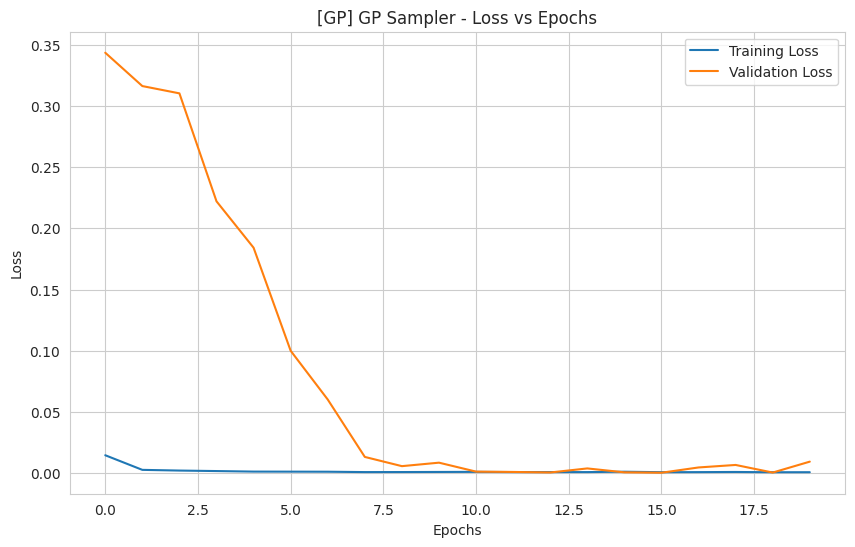

In [24]:
# Run optimizations
input_shape = (seq_length, 1)
random_params, random_metrics, random_history, random_model, random_y_pred = run_optimization(
    optuna.samplers.RandomSampler(), X_train, y_train, X_val, y_val, X_test, y_test, input_shape, "[RS] Random Sampler"
)
tpe_params, tpe_metrics, tpe_history, tpe_model, tpe_y_pred = run_optimization(
    optuna.samplers.TPESampler(), X_train, y_train, X_val, y_val, X_test, y_test, input_shape, "[TPE] TPE Sampler"
)
gp_params, gp_metrics, gp_history, gp_model, gp_y_pred = run_optimization(
    optuna.samplers.GPSampler(), X_train, y_train, X_val, y_val, X_test, y_test, input_shape, "[GP] GP Sampler"
)

## Comparison table
This part of the code I create a comparison table to evaluate the performance of three optimization techniques: `Random Search`, `Tree-structured Parzen Estimator`, and `Gaussian Process`. The best accuracy (`based on R²`) is ***converted into a percentage format*** for easier interpretation. Then, I print the table to provide a side-by-side comparison of the techniques, helping to assess their performance in terms of error metrics, accuracy, and time efficiency.

In [25]:
# Comparison table
def format_params(params):
  return (f"batch={params['batch_size']}, lstm_units={params['lstm_units']}, dropout={params['dropout_rate']:.2f}, "
  f"lr={params['learning_rate']:.6f}")

comparison_df = pd.DataFrame({
    'Technique': ['Random Search', 'Tree-Structure Parzen Estimator', 'Gaussian Process'],
    'Best Hyperparameters': [format_params(random_params), format_params(tpe_params), format_params(gp_params)],
    'MSE': [random_metrics['mse'], tpe_metrics['mse'], gp_metrics['mse']],
    'MAE': [random_metrics['mae'], tpe_metrics['mae'], gp_metrics['mae']],
    'MAPE': [random_metrics['mape'], tpe_metrics['mape'], gp_metrics['mape']],
    'SMAPE': [random_metrics['smape'], tpe_metrics['smape'], gp_metrics['smape']],
    'R²': [random_metrics['r2'], tpe_metrics['r2'], gp_metrics['r2']],
    'Tuning Time (s)': [random_metrics['training_time'], tpe_metrics['training_time'], gp_metrics['training_time']],
    'Best Accuracy': [random_metrics['r2'], tpe_metrics['r2'], gp_metrics['r2']]
})
for col in ['MSE', 'MAE', 'R²']:
    comparison_df[col] = comparison_df[col].map('{:.4f}'.format)
for col in ['MAPE', 'SMAPE']:
    comparison_df[col] = comparison_df[col].map('{:.2f}%'.format)
comparison_df['Tuning Time (s)'] = comparison_df['Tuning Time (s)'].map('{:.2f}'.format)
comparison_df['Best Accuracy'] = (comparison_df['Best Accuracy'].astype(float) * 100).map('{:.2f}%'.format)  # Converting R² to percentage

print("\nComparison of Optimization Techniques:")
comparison_df


Comparison of Optimization Techniques:


,Technique,Best Hyperparameters,MSE,MAE,MAPE,SMAPE,R²,Tuning Time (s),Best Accuracy
0,Random Search,"batch=32, lstm_units=160, dropout=0.11, lr=0.0...",56.0065,6.6270,3.87%,3.96%,0.8463,337.57,84.63%
1,Tree-Structure Parzen Estimator,"batch=16, lstm_units=64, dropout=0.14, lr=0.00...",10.1840,2.4606,1.54%,1.53%,0.9720,324.01,97.20%
2,Gaussian Process,"batch=32, lstm_units=256, dropout=0.20, lr=0.0...",9.8386,2.4253,1.52%,1.51%,0.9730,334.05,97.30%


A comparative analysis of three optimization techniques: Random Search, Tree-structured Parzen Estimator (TPE), and Gaussian Process, focusing on their performance metrics and efficiency.

- Random Search resulted in the lowest R² value of 0.8463, with a tuning time of 337.57 seconds. It also exhibited the highest MSE (56.0065) and MAE (6.6270), leading to a best accuracy of 84.63%. These results indicate that Random Search is less effective in fine-tuning hyperparameters compared to the other methods.

- TPE showed a significant improvement, achieving an R² of 0.9720 and reducing the MSE to 10.1840. Its tuning time was 324.01 seconds, slightly faster than Random Search, and it achieved a best accuracy of 97.20%, demonstrating a strong capability in optimizing model performance.

- Gaussian Process outperformed both methods, attaining the highest R² of 0.9730 and the lowest MSE (9.8386) and MAE (2.4253). Despite a slightly longer tuning time of 334.05 seconds, it achieved the highest best accuracy at 97.30%, making it the most effective optimization technique in this comparison.

In conclusion, among the three approaches, Gaussian Process demonstrated the best balance between accuracy and tuning efficiency, surpassing both Random Search and TPE in terms of predictive performance.

<hr>

This code prints the Best Accuracy (R²) for each optimization technique (Random Search, TPE, and Gaussian Process), converting the values into percentages for easier comparison.

In [26]:
# Best Accuracy
print("Best Accuracy por técnica:")
print(f"Random Search: {random_metrics['r2'] * 100:.2f}%")
print(f"TPE: {tpe_metrics['r2'] * 100:.2f}%")
print(f"Gaussian Process: {gp_metrics['r2'] * 100:.2f}%")

Best Accuracy por técnica:
Random Search: 84.63%
TPE: 97.20%
Gaussian Process: 97.30%


Identifies the best optimization method based on the highest R² value, then selects the corresponding predictions. It prints the method and plots a graph comparing the predicted vs. actual values for the best method.


Plotting Predicted vs Actual Values for the best method: Gaussian Process


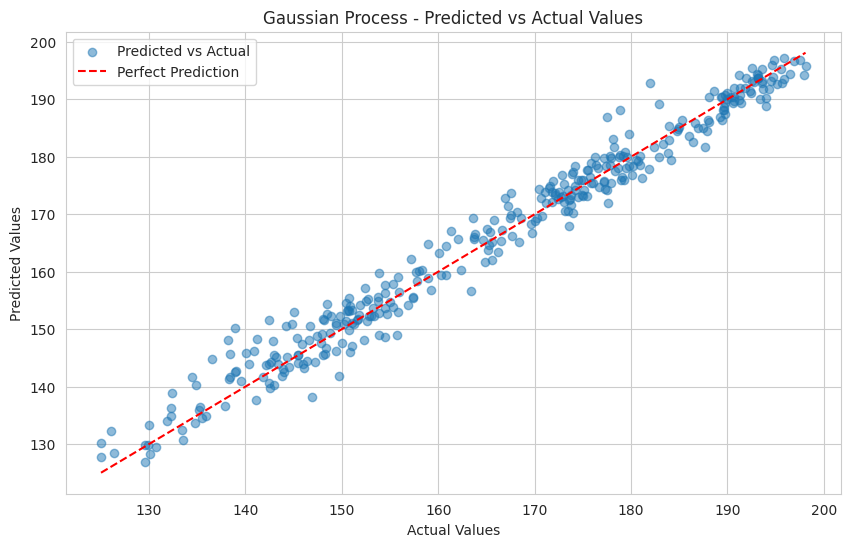

In [27]:
# Identify the best method based on MSE
best_method_idx = comparison_df['R²'].astype(float).idxmax()
best_method = comparison_df.loc[best_method_idx, 'Technique']
best_y_pred = {
    'Random Search': random_y_pred,
    'Tree-Structure Parzen Estimator': tpe_y_pred,
    'Gaussian Process': gp_y_pred
}[best_method]

# Plot Predicted vs Actual for the best method
print(f"\nPlotting Predicted vs Actual Values for the best method: {best_method}")
plot_predicted_vs_actual(y_test, best_y_pred, best_method)

This cell is generating a plot to compare the actual vs predicted values for the test set. It first extracts the corresponding test dates, then denormalizes both the true values and the best model's predictions. The plot shows actual values in blue and predicted values in red.

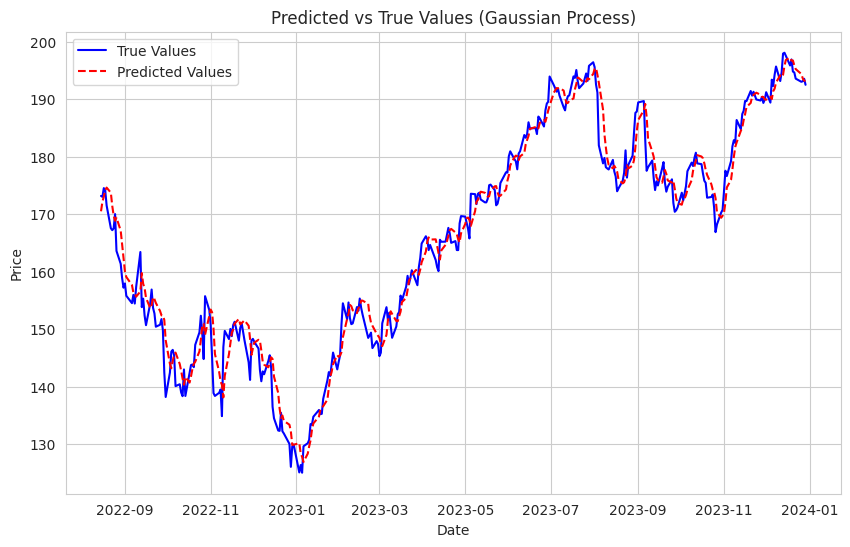

In [28]:
# Get corresponding test set dates
test_start_idx = train_size + val_size + seq_length  # Test set start index in the original dataset
test_dates = df_filtered.index[test_start_idx:test_start_idx + len(y_test)]  # Test set dates

# Select actual and predicted values from the best model (already denormalized)
y_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()  # Actual values
y_pred_best = scaler.inverse_transform(best_y_pred.reshape(-1, 1)).flatten()  # Best model predictions

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(test_dates, y_actual, label='True Values', color='blue')  # Actual values
plt.plot(test_dates, y_pred_best, label='Predicted Values', color='red', linestyle='--')  # Predicted values

# Chart settings
plt.legend()
plt.title(f'Predicted vs True Values ({best_method})')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()


  ## Prediction for best parameter
  This cell prepares the data by normaliznig the historic closing prices. It selects the best model based on the chosen method and generates predictions for the next 60 days. The future predictions are denormalized, and the code plots the historical data (train +test), future predictions, and adds shaded areas for training, testing, and future prediction periods.

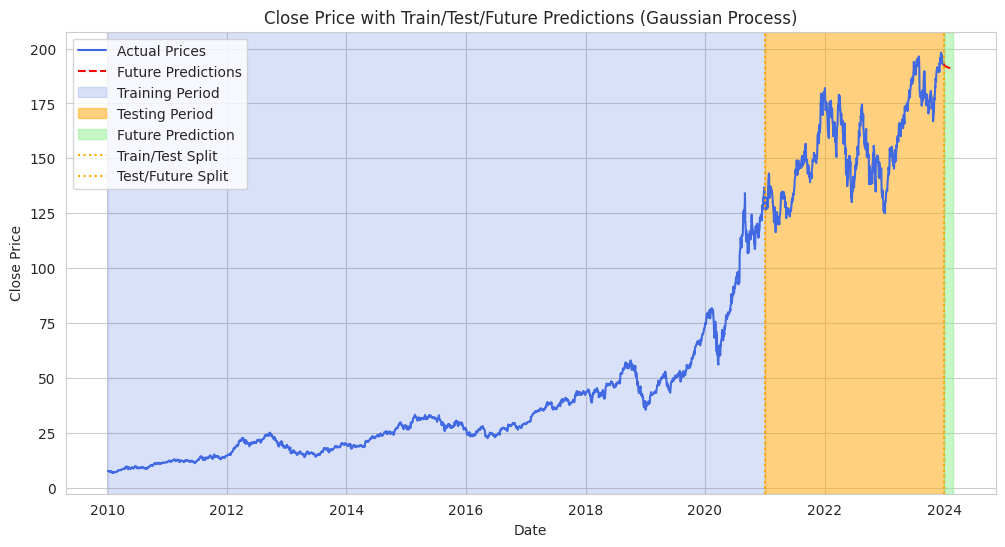

In [29]:
# Prepare data
df_close = df_filtered['Close'].values  # Full historical data
df_close_scale = scaler.transform(df_close.reshape(-1, 1))  # Normalize data

# Select the best model based on the best method
best_model = {
    'Random Search': random_model,
    'Tree-Structure Parzen Estimator': tpe_model,
    'Gaussian Process': gp_model
}[best_method]

# Generate future predictions using the best model
future_predictions = []
last_sequence = df_close_scale[-seq_length:]  # Last sequence from historical data

for _ in range(60):  # Predict 60 days ahead
    input_data = last_sequence.reshape(1, seq_length, 1)
    predicted_price = best_model.predict(input_data, verbose=0)
    future_predictions.append(predicted_price[0, 0])
    last_sequence = np.append(last_sequence[1:], predicted_price, axis=0)

# Denormalize future predictions
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1)).flatten()

# Create future dates
future_dates = pd.date_range(df_filtered.index[-1], periods=61, freq='D')[1:]

# Define split dates
train_end_date = df_filtered.index[train_size - 1]  # Last training date
test_start_date = df_filtered.index[train_size]     # First test date
test_end_date = df_filtered.index[-1]               # Last test date (latest historical data)

# Create the plot
plt.figure(figsize=(12, 6))

# Plot historical data (train + test)
plt.plot(df_filtered.index, df_close, label='Actual Prices', color='royalblue')

# Plot future predictions
plt.plot(future_dates, future_predictions, label='Future Predictions', linestyle='--', color='red')

# Add shaded areas
plt.axvspan(df_filtered.index[0], train_end_date, color='royalblue', alpha=0.2, label='Training Period')
plt.axvspan(test_start_date, test_end_date, color='orange', alpha=0.5, label='Testing Period')
plt.axvspan(test_end_date, future_dates[-1], color='lightgreen', alpha=0.5, label='Future Prediction')

# Add vertical lines
plt.axvline(x=train_end_date, color='orange', linestyle=':', label='Train/Test Split')
plt.axvline(x=test_end_date, color='orange', linestyle=':', label='Test/Future Split')

# Chart settings
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.title(f'Close Price with Train/Test/Future Predictions ({best_method})')
plt.show()

## Explanability
For the explainability, I created a visualization with SHAP library to explain predictions from the best model. It selects a sample from the test set, reshapes it, and prepares the data for SHAP. Then define a prediction function and initializes a KernelExplainer. The SHAP values are computed for the samples, and a force plot is displayed for the feature contributions to the model's prediction. The plot illustrates how each feature impacts the model's output, providing insight into the model's decision-making process.

  0%|          | 0/1 [00:00<?, ?it/s]

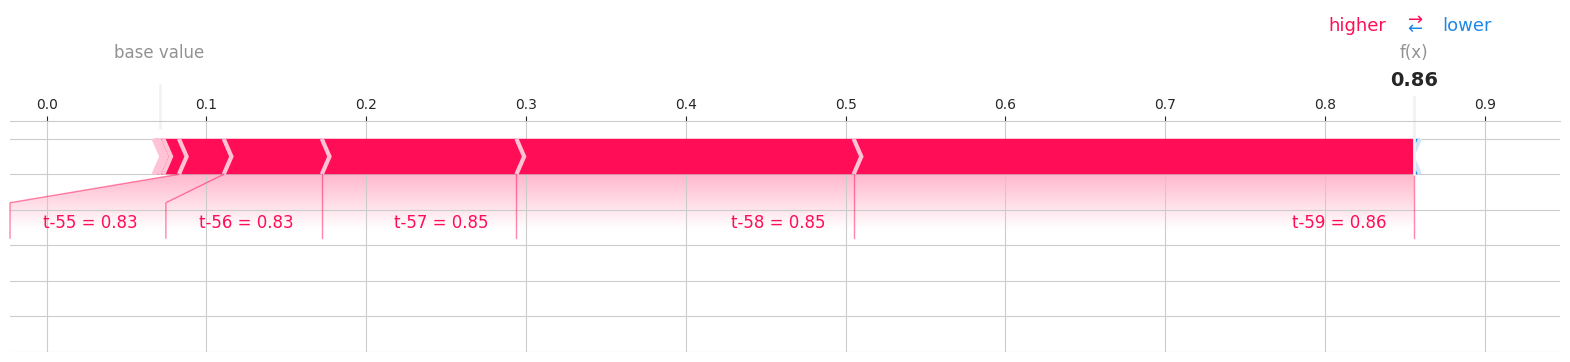

In [35]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Select the model
model = best_model

# Prepare data for SHAP
background_data = X_train[:100]  # 100 samples
sample_idx = 0  # Index of the test sample to explain
sample_to_explain = X_test[sample_idx]  # Select the sample

# Reshape the sample to 2D for SHAP
sample_to_explain_reshaped = sample_to_explain.reshape(1, -1)  # (1, seq_length * features)

def predict_function(X):
    # Reshape back to 3D for LSTM prediction
    X_reshaped = X.reshape(X.shape[0], seq_length, 1)
    return model.predict(X_reshaped, verbose=0)

# Create SHAP explainer
explainer = shap.KernelExplainer(predict_function, background_data.reshape(background_data.shape[0], -1))

# Compute SHAP values
shap_values = explainer.shap_values(sample_to_explain_reshaped)

# Rounds features values to decimal
sample_to_explain_rounded = np.round(sample_to_explain[:, 0], decimals=2)

# Visualize
shap.force_plot(
    explainer.expected_value[0],
    shap_values[0].reshape(seq_length, 1)[:, 0],  # Reshape to (seq_length,) and select first column
    features=sample_to_explain_rounded,  # Use rounded values
    feature_names=[f"t-{i}" for i in range(seq_length)],
    matplotlib=True  # Uses Matplotlib to render the plot (no need for JavaScript)
)

plt.show()

The most recent timesteps (t-0 isn't shown, but t-1, t-2, etc., is in the grouped values) and older ones `(t-55, t-59)` seem to have a significant impact on the prediction. This suggests the model captures both long-term trends (older timesteps) and recent patterns.

- **Consistency:** The lack of negative contributions indicates there were no conflicting signals in the past data suggesting a price drop.

- **Practical interpretation:** When transforming the normalized values back to actual prices, it is possible to interpret it as the model predicting a price of 100 because the high prices from 55, 56, 57, 58 and 59 days ago contributed to the increase in the prediction.

The **Force Plot** shows that the model's prediction for the chosen sample `(f(x) = 0.86)` was mainly influenced by positive contributions from past timesteps (such as t-59, t-58, t-57, t-56, t-55), which pushed the prediction higher compared to the baseline value `(0.80)`. This indicates that the closing prices on the days corresponding to these timesteps were consistent with a higher prediction.

## Conclusion
In this project, the application of LSTM neural networks for stock market prediction was explored, leveraging historical Apple Inc. stock data. The choice of `LSTM` was justified by its ability to capture temporal dependencies, mitigate the vanishing gradient problem, and effectively model non-linear financial patterns.     

Through extensive data preprocessing, including normalization and sequence generation, we structured the dataset to optimize LSTM training. The data was split into `training`, `validation`, and `test` sets, ensuring robust model evaluation. Visualizations of historical trends and trading volumes further helped contextualize the stock price movements.     

Hyperparameter optimization was performed using Optuna with three different search strategies: Random Search, TPE, and Gaussian Process. The results demonstrated that Gaussian Process optimization outperformed the other methods, achieving the highest R² value of 0.973 `(97.30% accuracy)` and the shortest tuning time of `334.05 seconds`. This optimization method provided the best trade-off between accuracy and computational efficiency.     

Model performance was evaluated using key metrics such as `MSE, MAE, SMAPE`, and `R²`, confirming the model's predictive capability. The predicted values closely followed actual stock prices, as observed in the predicted vs. actual comparison plots. Further explainability analysis using `SHAP` revealed that both recent and long-term historical stock prices significantly influenced predictions, reinforcing the model's ability to learn meaningful trends in financial data.     

Finally, leveraging the best-trained model generates future stock price predictions for the next `60 days`. The forecast visualization illustrated expected price trends based on historical patterns, providing insights for potential market movements.    

Overall, the implementation of LSTMs combined with advanced hyperparameter tuning and explainability techniques demonstrated a powerful approach for stock market forecasting. Future work could focus on incorporating external financial indicators, news sentiment analysis, and alternative deep learning architectures to further enhance predictive performance.


## References
- ML Optimization Strategies - Lectures (FOL) from week 2 to week 10: https://www.fanshaweonline.ca/d2l/le/content/1899422/Home

- Time series forecasting: https://www.tensorflow.org/tutorials/structured_data/time_series

- Optuna API Reference https://optuna.readthedocs.io/en/stable/reference/samplers/generated/optuna.samplers.TPESampler.html

- Optuna vs GridSearchCV vs RandomSearchCV - Hyperparameter Tuning Techniques: https://medium.com/@abhishekjainindore24/optuna-vs-gridsearchcv-vs-randomsearchcv-hyperparameter-tuning-techniques-ea8e2ada28d0

- SHAP KernelExplainer: https://shap.readthedocs.io/en/latest/generated/shap.KernelExplainer.html#shap.KernelExplainer
